# Análise Climática Brasileira


In [1]:
#Importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy

### 1 - Carregando e inspecionando os dados

In [2]:
# Carregando a base de dados

df = pd.read_csv("clima_brasil.csv")

# Inspeção dos dados
print(df.shape)
print("\n-----------------------------------------------\n")
print(df.info())
print("\n-----------------------------------------------\n")
print(df.isnull().sum())
print("\n-----------------------------------------------\n")
print(df.describe())
print("\n-----------------------------------------------\n")
print(df.describe(include='object'))
print("\n-----------------------------------------------\n")
print(df.head(10))
print("\n-----------------------------------------------\n")
print(df.tail(5))


(1320, 15)

-----------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   data         1320 non-null   object 
 1   ano          1320 non-null   int64  
 2   mes          1320 non-null   int64  
 3   nome_mes     1320 non-null   object 
 4   cidade       1320 non-null   object 
 5   regiao       1320 non-null   object 
 6   latitude     1320 non-null   float64
 7   longitude    1320 non-null   float64
 8   temp_max     1320 non-null   float64
 9   temp_min     1320 non-null   float64
 10  temp_media   1290 non-null   float64
 11  umidade_pct  1309 non-null   float64
 12  chuva_mm     1295 non-null   float64
 13  vento_kmh    1320 non-null   float64
 14  pressao_hpa  1320 non-null   float64
dtypes: float64(9), int64(2), object(4)
memory usage: 154.8+ KB
None

-----------------------------------------------


## Etapa 1 — Entendendo o Dataset

**Estrutura:** 1.320 registros, 15 colunas, período 2020–2024.
**22 cidades** distribuídas em **5 regiões** do Brasil.

**Tipos de dados:**
- `data` está como object — precisa converter para datetime
- `nome_mes` está em inglês — pode ser útil traduzir
- Demais tipos estão corretos

**Valores nulos encontrados:**
- `temp_media`  : 30 nulos (2.3%)
- `chuva_mm`    : 25 nulos (1.9%)
- `umidade_pct` : 11 nulos (0.8%)

**Problemas nos valores:**
- `temp_max` mínimo = -1.7°C e máximo = 51.7°C
  → -1.7°C pode ser real no Sul em inverno rigoroso
  → 51.7°C é irreal no Brasil — outlier a tratar
- `temp_media` máximo = 31.2°C — plausível
- `chuva_mm` máximo = 402.1mm — alto mas possível em Belém



In [3]:
# Investigando as temperaturas
print(df[df['temp_max'] < 5][['cidade', 'regiao', 'mes', 'temp_max']])

        cidade   regiao  mes  temp_max
10      Macapá    Norte    7       4.3
129  São Paulo  Sudeste   10      -1.7
626   Curitiba      Sul    7       0.0


## Decisão sobre outliers de temp_max

- **Macapá 4.3°C em julho**: impossível geograficamente.
  Macapá está a 3° do equador — temperatura nunca cai abaixo de 20°C.
  → Tratar como outlier

- **São Paulo -1.7°C em outubro**: impossível sazonalmente.
  Outubro é primavera no Sudeste — geadas não ocorrem nesse período.
  → Tratar como outlier

- **Curitiba 0.0°C em julho**: limite mas plausível.
  Curitiba já registrou temperaturas próximas de zero em julho.
  → Manter

**Estratégia:** substituir outliers pela mediana da cidade no mesmo mês
— mais preciso do que a mediana geral.

In [4]:
# Criando cópia
df_copy = df.copy()

### 2 - Limpar e tratar inconsistências

In [5]:
# Convertendo data pra de object pra datatime
df_copy["data"] = pd.to_datetime(df_copy["data"])

In [6]:
# Tratando outliers de temperatura
temp_max = 44.8
temp_min = 5.0

mask = (df_copy["temp_max"] > temp_max) | (df_copy["temp_max"] < temp_min)

# Substituindo pela mediana da cidade no mesmo mês
df_copy.loc[mask, 'temp_max'] = df_copy.groupby(['cidade', 'mes'])['temp_max'].transform('median')[mask]



In [7]:
# Tratando nulos
for col in ['temp_media', 'chuva_mm', 'umidade_pct']:
  df_copy[col] = df_copy.groupby(['cidade', 'mes'])[col].transform(lambda x: x.fillna(x.median()))

In [8]:
# Traduzindo o nome dos meses
traducao = {
    'January':'Janeiro', 'February':'Fevereiro', 'March':'Março',
    'April':'Abril',     'May':'Maio',            'June':'Junho',
    'July':'Julho',      'August':'Agosto',       'September':'Setembro',
    'October':'Outubro', 'November':'Novembro',   'December':'Dezembro'
}
df_copy['nome_mes'] = df_copy['nome_mes'].map(traducao)


In [9]:
# Verificação
print(df_copy.isnull().sum())
print(df_copy[['temp_max', 'temp_min', 'temp_media']].describe())

data           0
ano            0
mes            0
nome_mes       0
cidade         0
regiao         0
latitude       0
longitude      0
temp_max       0
temp_min       0
temp_media     0
umidade_pct    0
chuva_mm       0
vento_kmh      0
pressao_hpa    0
dtype: int64
          temp_max     temp_min   temp_media
count  1320.000000  1320.000000  1320.000000
mean     24.764545    15.642576    20.215227
std       4.286720     4.610476     4.322151
min       6.100000     0.800000     5.900000
25%      22.275000    12.800000    17.800000
50%      25.200000    16.000000    20.700000
75%      27.900000    18.900000    23.400000
max      44.500000    27.900000    31.200000


### 3 - Análise Exploratória

In [10]:
# Região

print(df_copy.groupby('regiao')[['temp_media', 'temp_max', 'temp_min', 'chuva_mm']].mean().sort_values('temp_media', ascending=False))

              temp_media   temp_max   temp_min    chuva_mm
regiao                                                    
Nordeste       23.196071  27.708810  18.656429  122.255714
Norte          22.528542  27.010000  18.035000  252.571042
Centro-Oeste   19.957292  24.471667  15.464167  129.657708
Sudeste        17.788958  22.439583  13.092500  124.061875
Sul            13.754444  18.391111   9.058333   84.875278


## Temperatura e Chuva por Região

**Temperatura:**
- Nordeste é a região mais quente (23.2°C de média)
- Sul é a mais fria (13.8°C) — diferença de quase 10°C em relação ao Nordeste
- Norte surpreende por ser a 2ª mais quente mas não a 1ª — a altitude
  de algumas cidades do Nordeste explica temperaturas mais altas

**Chuva:**
- Norte é de longe a mais chuvosa (252mm de média mensal)
- Sul é a menos chuvosa (84mm) — chuvas bem distribuídas ao longo do ano
- Nordeste tem média baixa (122mm) mas com grande variação entre cidades

In [11]:
# Tabela Dinâmica - temperatura
print(df_copy.pivot_table(index='regiao', columns='mes', values='temp_media'))

mes                  1          2          3          4          5   \
regiao                                                                
Centro-Oeste  19.487500  21.075000  21.810000  22.705000  22.070000   
Nordeste      23.108571  24.811429  25.181429  25.291429  25.805714   
Norte         22.500000  24.205000  24.055000  25.587500  24.340000   
Sudeste       17.530000  18.772500  20.290000  20.165000  19.532500   
Sul           13.486667  11.706667   9.720000   9.940000  11.820000   

mes                  6          7          8          9          10  \
regiao                                                                
Centro-Oeste  20.435000  19.125000  19.395000  18.060000  17.675000   
Nordeste      24.845714  22.494286  21.991429  21.234286  20.880000   
Norte         23.955000  22.370000  20.995000  20.522500  20.285000   
Sudeste       18.922500  17.890000  16.530000  15.820000  15.415000   
Sul           11.620000  13.100000  16.013333  17.246667  17.386667   

mes 

##  Temperatura Média por Região e Mês

**Sazonalidade do Sul:**
- Padrão invertido claro — janeiro (13.5°C) é o mais quente
  e junho/julho os mais frios (11.6°C e 13.1°C)
- Maior amplitude térmica do Brasil entre os meses

**Nordeste:**
- Pouca variação ao longo do ano — entre 20.9°C e 25.8°C
- Mês mais quente: maio (25.8°C) — antes do período chuvoso

**Norte:**
- Também estável — entre 20.3°C e 25.6°C
- Sem inverno definido, como esperado para região equatorial

**Sudeste e Centro-Oeste:**
- Sazonalidade moderada — verão claramente mais quente
  e inverno com quedas relevantes

In [12]:
# Tabela Dinâmica - chuva
print(df_copy.pivot_table(index='regiao', columns='mes', values='chuva_mm'))

mes                   1           2           3           4           5   \
regiao                                                                     
Centro-Oeste   78.547500  109.125000  124.355000  153.835000  168.635000   
Nordeste       77.772857   94.528571  115.737143  146.325714  167.220000   
Norte         212.865000  216.665000  245.392500  280.697500  297.000000   
Sudeste        85.410000   93.232500  113.780000  158.850000  171.557500   
Sul           123.753333  103.106667   91.466667   65.533333   50.283333   

mes                   6           7         8           9           10  \
regiao                                                                   
Centro-Oeste  191.055000  173.080000  146.3350  130.660000  106.255000   
Nordeste      170.442857  177.322857  147.2200  116.057143   99.122857   
Norte         304.862500  292.675000  271.6250  254.570000  236.770000   
Sudeste       174.565000  160.595000  156.2575  119.560000  111.980000   
Sul            40.82000

##  Chuva Média por Região e Mês

**Norte:**
- Região mais chuvosa em todos os meses sem exceção
- Pico em junho (304mm) — período chuvoso amazônico
- Mesmo no mês mais seco (fevereiro, 216mm) supera todas as outras regiões

**Sul:**
- Padrão inverso às outras regiões — mais chuva no verão (jan: 123mm)
  e menos no inverno (julho: 48mm)
- Única região com chuvas bem distribuídas — sem seca definida

**Nordeste e Centro-Oeste:**
- Padrão semelhante — chuvas concentradas de abril a agosto
- Nordeste quase seco em dezembro e janeiro (77mm)

**Sudeste:**
- Seca clara de junho a agosto — típico clima tropical de altitude

### 4 - Teste de hipotese


In [13]:
#Separando nordeste
nordeste = df_copy[df_copy['regiao'] == 'Nordeste']
# Separando sul
sul = df_copy[df_copy['regiao'] == 'Sul']
# Rodando t-test
stat, p_valor = scipy.stats.ttest_ind(nordeste['temp_media'], sul['temp_media'])

print(f'Média Nordeste : {nordeste["temp_media"].mean():.2f}°C')
print(f'Média Sul      : {sul["temp_media"].mean():.2f}°C')
print(f'Diferença      : {nordeste["temp_media"].mean() - sul["temp_media"].mean():.2f}°C')
print(f'\nEstatística t  : {stat:.4f}')
print(f'p-value        : {p_valor:.10f}')

Média Nordeste : 23.20°C
Média Sul      : 13.75°C
Diferença      : 9.44°C

Estatística t  : 36.1212
p-value        : 0.0000000000


## Conclusão do Teste de Hipótese

**H0 (Hipótese Nula):** a temperatura média do Nordeste é igual
à temperatura média do Sul.

**H1 (Hipótese Alternativa):** as temperaturas são diferentes.

**Resultados:**
- Média Nordeste : 23.20°C
- Média Sul      : 13.75°C
- Diferença      : 9.44°C
- Estatística t  : 36.12
- p-value        : ≈ 0.0 (menor que 0.0000000001)

**Conclusão:**
O p-value é extremamente menor que 0.05 — rejeitamos H0.
A diferença de 9.44°C entre as regiões não é aleatória,
é estatisticamente significativa.

Na prática isso confirma o que geograficamente já esperávamos:
o Nordeste e o Sul do Brasil possuem climas completamente distintos,
com o Nordeste sendo em média 9°C mais quente ao longo do ano.

### 5 - Amostragem

In [14]:
# Tirando 3 amostragens
amostra_05 = df_copy.sample(frac=0.05, random_state=42)
amostra_10 = df_copy.sample(frac=0.10, random_state=42)
amostra_30 = df_copy.sample(frac=0.30, random_state=42)

# Comparando as amostras com a população completa
comparacao = pd.DataFrame({
    'Populacao'  : df_copy.groupby('regiao')['temp_media'].mean(),
    'Amostra_5%' : amostra_05.groupby('regiao')['temp_media'].mean(),
    'Amostra_10%': amostra_10.groupby('regiao')['temp_media'].mean(),
    'Amostra_30%': amostra_30.groupby('regiao')['temp_media'].mean(),
}).round(2)
print(comparacao)

              Populacao  Amostra_5%  Amostra_10%  Amostra_30%
regiao                                                       
Centro-Oeste      19.96       19.36        20.68        19.82
Nordeste          23.20       23.12        23.27        23.27
Norte             22.53       22.78        22.65        22.53
Sudeste           17.79       17.25        17.82        17.98
Sul               13.75       12.00        11.73        12.87


## Conclusão da Amostragem

**Populacao vs Amostras — Temperatura média por região (°C):**

| Região | População | 5% | 10% | 30% |
|---|---|---|---|---|
| Nordeste | 23.20 | 23.12 | 23.27 | 23.27 |
| Norte | 22.53 | 22.78 | 22.65 | 22.53 |
| Centro-Oeste | 19.96 | 19.36 | 20.68 | 19.82 |
| Sudeste | 17.79 | 17.25 | 17.82 | 17.98 |
| Sul | 13.75 | 12.00 | 11.73 | 12.87 |

**Observações:**

- **Nordeste e Norte** se mantiveram estáveis mesmo com 5% —
  regiões com mais cidades no dataset representam bem com amostras pequenas

- **Sul foi o mais instável** — com apenas 5% (≈9 registros)
  a média caiu para 12.00°C, distante dos 13.75°C reais.
  Com 30% ainda não convergiu completamente.

- **Conclusão geral:** amostras de 10% já representam bem regiões
  com muitos dados. Para regiões sub-representadas como o Sul,
  amostras maiores ou amostragem estratificada por região
  seriam mais adequadas.

### 6 - Visualização

Text(0.5, 1.0, 'Correlação entre todas as variáveis númericas')

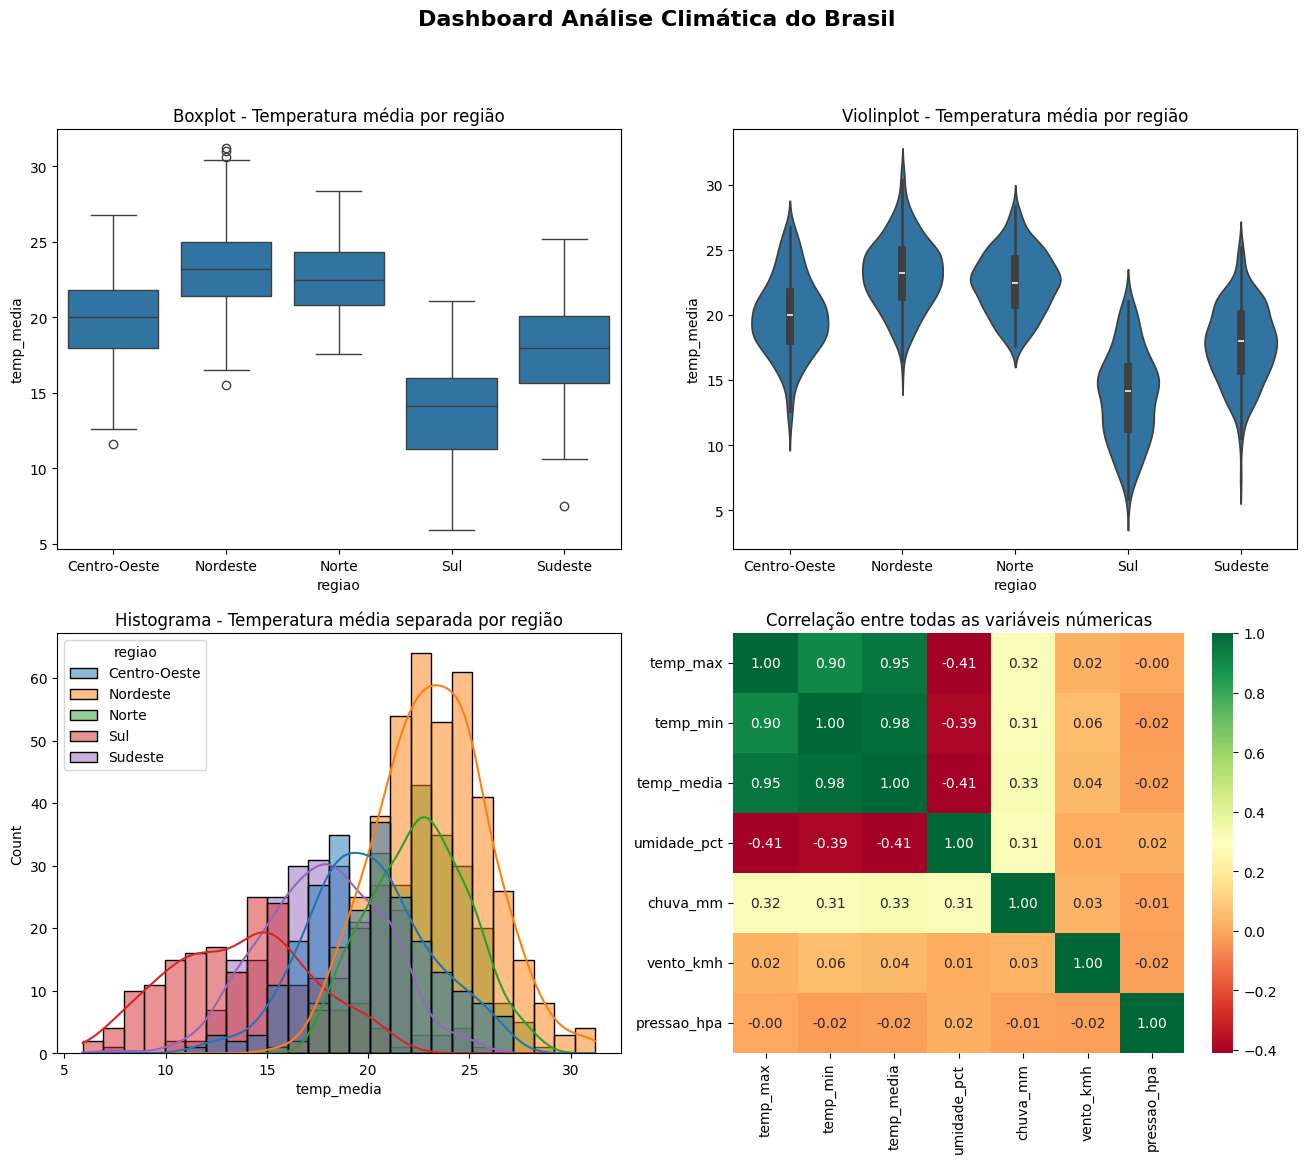

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Dashboard Análise Climática do Brasil', fontsize=16, fontweight='bold')

# Boxplot

sns.boxplot(data=df_copy, x='regiao', y='temp_media', ax=axes[0,0])
axes[0, 0].set_title('Boxplot - Temperatura média por região')

# Vionlinplot

sns.violinplot(data=df_copy, x='regiao', y='temp_media', ax=axes[0,1])
axes[0, 1].set_title('Violinplot - Temperatura média por região')

#Histograma

sns.histplot(data=df_copy, x='temp_media', hue='regiao', kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Histograma - Temperatura média separada por região')

#Heatmap

colunas = ['temp_max','temp_min','temp_media','umidade_pct','chuva_mm','vento_kmh','pressao_hpa']
sns.heatmap(df_copy[colunas].corr(), annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1,1])
axes[1, 1].set_title('Correlação entre todas as variáveis númericas')

## Conclusões Gerais — Análise Climática Brasileira

1. O Brasil possui climas radicalmente diferentes entre regiões —
   diferença de até 9.4°C entre Nordeste e Sul (confirmado pelo t-test)

2. O Norte é a região mais chuvosa (média 252mm/mês) e o Sul
   a mais seca (84mm/mês) com distribuição mais uniforme

3. A sazonalidade é mais intensa no Sul e quase inexistente
   no Norte e Nordeste

4. Amostras aleatórias simples de 10% representam bem regiões
   com muitos dados, mas sub-representam regiões menores como o Sul

5. Umidade e temperatura têm relação inversa (-0.41) —
   regiões quentes tendem a ser menos úmidas

In [16]:
# Exportando

df_copy.to_csv('clima_limpo.csv', index=False, encoding='utf-8-sig')
print(f'✅ Arquivo exportado!')
print(f'   Linhas  : {len(df_copy):,}')
print(f'   Colunas : {len(df_copy.columns)}')

✅ Arquivo exportado!
   Linhas  : 1,320
   Colunas : 15
